#Business Understanding

วิเคราะห์ข้อมูลการแจ้งเหตุความรุนแรงในครอบครัว เพื่อศึกษาลักษณะของเหตุการณ์ ผู้กระทำ และผู้ถูกกระทำ รวมถึงค้นหาแนวโน้มที่อาจเป็นประโยชน์ต่อการกำหนดนโยบาย

#Import libraiy ที่จำเป็น

In [ ]:
!pip install plotly kaleido -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
import seaborn as sns
#import warnings
#warnings.filterwarnings('ignore')

#ดาวน์โหลดฟอนต์ภาษาไทย (TH Sarabun New)
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf
mpl.font_manager.fontManager.addfont('thsarabunnew-webfont.ttf')
mpl.rc('font', family='TH Sarabun New', size=16)
sns.set_theme(style="whitegrid", font="TH Sarabun New")

plt.rcParams['figure.dpi'] = 120


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 4.0 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#รับ Dataset และสร้างตัวแปรเก็บค่าไว้

In [ ]:
df_case = pd.read_csv('/content/drive/MyDrive/dataset hack1/ข้อมูลการแจ้งเหตุความรุนแรงในครอบครัว.csv')
df_offender = pd.read_csv('/content/drive/MyDrive/dataset hack1/ข้อมูลผู้กระทำความรุนแรงในครอบครัว.csv')
df_victim = pd.read_csv('/content/drive/MyDrive/dataset hack1/ข้อมูลผู้ถูกกระทำความรุนแรงในครอบครัว.csv')

#Check DataOverview

In [ ]:
def check_data(datasets):
    for name, df in datasets.items():

        print("=" * 70)
        print(f"{name}")
        print("=" * 70)

        # 1. Shape
        print("1. ขนาดข้อมูล")
        print(f"Rows    : {df.shape[0]}")
        print(f"Columns : {df.shape[1]}")

        # 2. Columns
        print("\n2. ชื่อคอลัมน์")
        print(df.columns.to_list())

        # 3. Info
        print("\n3. Data Info")
        df.info()

        # 4. Summary
        print("\n4. Summary Statistics")
        print(df.describe())

        # 5. Missing
        print("\n5. Missing Values")
        print(df.isna().sum())

        # 6. Preview
        print("\n6. ตัวอย่างข้อมูล")
        display(df.head())

        print("\n")

In [ ]:
datasets = {
    "CASE": df_case,
    "OFFENDER": df_offender,
    "VICTIM": df_victim
}

check_data(datasets)

CASE
1. ขนาดข้อมูล
Rows    : 877
Columns : 11

2. ชื่อคอลัมน์
['Regional', 'Province', 'District', 'Sub-District', 'Derivation', 'Source', 'Source Type', 'Other Source Type', 'Channel', 'Period', 'Locale']

3. Data Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 877 entries, 0 to 876
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Regional           877 non-null    object
 1   Province           877 non-null    object
 2   District           877 non-null    object
 3   Sub-District       877 non-null    object
 4   Derivation         877 non-null    object
 5   Source             877 non-null    object
 6   Source Type        877 non-null    object
 7   Other Source Type  877 non-null    object
 8   Channel            877 non-null    object
 9   Period             877 non-null    object
 10  Locale             877 non-null    object
dtypes: object(11)
memory usage: 75.5+ KB

4. Summary Statistics

,Regional,Province,District,Sub-District,Derivation,Source,Source Type,Other Source Type,Channel,Period,Locale
0,ภาคกลาง,กรุงเทพมหานคร,เขตหนองจอก,ลำผักชี,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,หนังสือราชการหรือหนังสือจากหน่วยงาน,12:01 – 18:00,สถานที่ส่วนบุคคล
1,ภาคกลาง,กรุงเทพมหานคร,เขตบางแค,บางแค,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,หนังสือราชการหรือหนังสือจากหน่วยงาน,12:01 – 18:00,สถานที่ส่วนบุคคล
2,ภาคกลาง,กรุงเทพมหานคร,เขตทวีวัฒนา,ศาลาธรรมสพน์,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,ระบบ,18:01 – 00:00,สถานที่ส่วนบุคคล
3,ภาคกลาง,กรุงเทพมหานคร,เขตบางซื่อ,วงศ์สว่าง,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,ระบบ,06:01 – 12:00,สถานที่ส่วนบุคคล
4,ภาคกลาง,กรุงเทพมหานคร,เขตประเวศ,ดอกไม้,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,ระบบ,00:01 – 06:00,สถานที่ส่วนบุคคล




OFFENDER
1. ขนาดข้อมูล
Rows    : 564
Columns : 19

2. ชื่อคอลัมน์
['Regional', 'Province', 'District', 'Sub-District', 'Gender', 'Age', 'Age Range', 'Relation', 'Mariage Registration', 'Alcohol', 'Drug', 'Authoritative', 'Rage', 'Jealous', 'Divorce', 'Health Problem', 'Mental Problem', 'Gambling Addict', 'Economics Stress']

3. Data Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 564 entries, 0 to 563
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Regional              564 non-null    object
 1   Province              564 non-null    object
 2   District              564 non-null    object
 3   Sub-District          564 non-null    object
 4   Gender                564 non-null    object
 5   Age                   564 non-null    int64 
 6   Age Range             564 non-null    object
 7   Relation              564 non-null    object
 8   Mariage Registration  564 non-null    object
 9 

,Regional,Province,District,Sub-District,Gender,Age,Age Range,Relation,Mariage Registration,Alcohol,Drug,Authoritative,Rage,Jealous,Divorce,Health Problem,Mental Problem,Gambling Addict,Economics Stress
0,ภาคกลาง,กรุงเทพมหานคร,เขตหนองจอก,ลำผักชี,หญิง,61,วัยสูงอายุ 60 ปีขึ้นไป,โสด,ไม่ระบุ,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่
1,ภาคกลาง,กรุงเทพมหานคร,เขตบางแค,บางแค,หญิง,26,วัยผู้ใหญ่ตอนต้น 19 - 35 ปี,โสด,ไม่ระบุ,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่
2,ภาคกลาง,กรุงเทพมหานคร,เขตทวีวัฒนา,ศาลาธรรมสพน์,หญิง,55,วัยกลางคน 36 - 59 ปี,โสด,ไม่ระบุ,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่
3,ภาคกลาง,กรุงเทพมหานคร,เขตบางซื่อ,วงศ์สว่าง,หญิง,64,วัยสูงอายุ 60 ปีขึ้นไป,แยกกันอยู่,จดทะเบียนหย่า,ไม่,ไม่,ใช่,ใช่,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่
4,ภาคกลาง,กรุงเทพมหานคร,เขตประเวศ,ดอกไม้,ชาย,33,วัยผู้ใหญ่ตอนต้น 19 - 35 ปี,สมรส,ยังไม่ได้จดทะเบียนสมรส,ใช่,ไม่,ไม่,ใช่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่




VICTIM
1. ขนาดข้อมูล
Rows    : 597
Columns : 20

2. ชื่อคอลัมน์
['Regional', 'Province', 'District', 'Sub-District', 'Gender', 'Age', 'Age Range', 'Relation', 'Mariage Registration', 'Alcohol', 'Drug', 'Authoritative', 'Rage', 'Jealous', 'Divorce', 'Health Problem', 'Mental Problem', 'Gambling Addict', 'Economics Stress', 'Relation Type']

3. Data Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 597 entries, 0 to 596
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Regional              597 non-null    object
 1   Province              597 non-null    object
 2   District              597 non-null    object
 3   Sub-District          597 non-null    object
 4   Gender                597 non-null    object
 5   Age                   597 non-null    int64 
 6   Age Range             597 non-null    object
 7   Relation              597 non-null    object
 8   Mariage Registration  597 non-nul

,Regional,Province,District,Sub-District,Gender,Age,Age Range,Relation,Mariage Registration,Alcohol,Drug,Authoritative,Rage,Jealous,Divorce,Health Problem,Mental Problem,Gambling Addict,Economics Stress,Relation Type
0,ภาคกลาง,กรุงเทพมหานคร,เขตหนองจอก,ลำผักชี,หญิง,18,วัยรุ่น 13 - 18 ปี,โสด,ไม่ระบุ,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,ยาย
1,ภาคกลาง,กรุงเทพมหานคร,เขตบางแค,บางแค,หญิง,36,วัยกลางคน 36 - 59 ปี,โสด,ไม่ระบุ,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,พี่น้อง/ลูกพี่ลูกน้อง
2,ภาคกลาง,กรุงเทพมหานคร,เขตทวีวัฒนา,ศาลาธรรมสพน์,ชาย,78,วัยสูงอายุ 60 ปีขึ้นไป,แยกกันอยู่,ยังไม่ได้จดทะเบียนหย่า,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่,บุตร
3,ภาคกลาง,กรุงเทพมหานคร,เขตบางซื่อ,วงศ์สว่าง,หญิง,64,วัยสูงอายุ 60 ปีขึ้นไป,แยกกันอยู่,จดทะเบียนหย่า,ไม่,ไม่,ใช่,ใช่,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่,"คู่ชีวิต,สามี"
4,ภาคกลาง,กรุงเทพมหานคร,เขตประเวศ,ดอกไม้,หญิง,35,วัยผู้ใหญ่ตอนต้น 19 - 35 ปี,โสด,ไม่ระบุ,ใช่,ไม่,ไม่,ใช่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,"คู่ชีวิต,ภรรยา"


#   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Regional              564 non-null    object
 1   Province              564 non-null    object
 2   District              564 non-null    object
 3   Sub-District          564 non-null    object
 4   Gender                564 non-null    object
 5   Age                   564 non-null    int64
 6   Age Range             564 non-null    object
 7   Relation              564 non-null    object

#Check Data summarzie

In [ ]:
def summarzie_categories(dataset,cols,namedata):
  print(namedata)
  for col in cols:
    print(f'\n===== {col} =====')
    print(f'จำนวนรูปแบบที่ไม่ซ้ำกันมีทั้งหมด: {dataset[col].nunique()} ค่า')
    data_count=(dataset[col].value_counts())
    data_count_normazile=(dataset[col].value_counts(normalize=True)*100)
    df=pd.DataFrame({
      'จำนวน': data_count,
      'เปอร์เซ็นต์':data_count_normazile})
    display(df)

In [ ]:
summarzie_categories(
    df_victim,
    ['Gender', 'Age Range', 'Relation','District'],
    'ข้อมูลของผู้กระทำ'
)

ข้อมูลของผู้กระทำ

===== Gender =====
จำนวนรูปแบบที่ไม่ซ้ำกันมีทั้งหมด: 3 ค่า


,จำนวน,เปอร์เซ็นต์
Gender,,
หญิง,479,80.234506
ชาย,117,19.597990
ไม่ระบุเพศ,1,0.167504



===== Age Range =====
จำนวนรูปแบบที่ไม่ซ้ำกันมีทั้งหมด: 6 ค่า


,จำนวน,เปอร์เซ็นต์
Age Range,,
วัยกลางคน 36 - 59 ปี,175,29.313233
วัยผู้ใหญ่ตอนต้น 19 - 35 ปี,150,25.125628
วัยสูงอายุ 60 ปีขึ้นไป,108,18.090452
วัยรุ่น 13 - 18 ปี,75,12.562814
วัยเด็กตอนกลาง 7 - 12 ปี,58,9.715243
วัยเด็กเล็กแรกเกิด - 6 ปี,31,5.192630



===== Relation =====
จำนวนรูปแบบที่ไม่ซ้ำกันมีทั้งหมด: 4 ค่า


,จำนวน,เปอร์เซ็นต์
Relation,,
โสด,274,45.896147
สมรส,220,36.850921
แยกกันอยู่,61,10.217755
หม้าย (กรณีคู่สมรสเสียชีวิต),42,7.035176



===== District =====
จำนวนรูปแบบที่ไม่ซ้ำกันมีทั้งหมด: 308 ค่า


,จำนวน,เปอร์เซ็นต์
District,,
เมืองราชบุรี,14,2.345059
โพธาราม,12,2.010050
เมืองหนองคาย,9,1.507538
บางคล้า,9,1.507538
เมืองระยอง,7,1.172529
...,...,...
ควนกาหลง,1,0.167504
สะบ้าย้อย,1,0.167504
จะนะ,1,0.167504


In [ ]:
summarzie_categories(
    df_offender,
    ['Gender', 'Age Range', 'Relation'],
    'ข้อมูลของผู้กระทำ'
)

ข้อมูลของผู้กระทำ

===== Gender =====
จำนวนรูปแบบที่ไม่ซ้ำกันมีทั้งหมด: 3 ค่า


,จำนวน,เปอร์เซ็นต์
Gender,,
ชาย,461,81.737589
หญิง,102,18.085106
ไม่ระบุเพศ,1,0.177305



===== Age Range =====
จำนวนรูปแบบที่ไม่ซ้ำกันมีทั้งหมด: 5 ค่า


,จำนวน,เปอร์เซ็นต์
Age Range,,
วัยกลางคน 36 - 59 ปี,287,50.886525
วัยผู้ใหญ่ตอนต้น 19 - 35 ปี,206,36.524823
วัยสูงอายุ 60 ปีขึ้นไป,54,9.574468
วัยรุ่น 13 - 18 ปี,13,2.304965
วัยเด็กตอนกลาง 7 - 12 ปี,4,0.709220



===== Relation =====
จำนวนรูปแบบที่ไม่ซ้ำกันมีทั้งหมด: 4 ค่า


,จำนวน,เปอร์เซ็นต์
Relation,,
สมรส,259,45.921986
โสด,197,34.929078
แยกกันอยู่,92,16.312057
หม้าย (กรณีคู่สมรสเสียชีวิต),16,2.836879


#สร้าง function ทำการ Boolean indexing

In [ ]:
def clean_data(datasets,col,value_error):
  dataset_clean=[]
  for dataset in datasets:
    df_clean=dataset[dataset[col]!=value_error]
    dataset_clean.append(df_clean)
  return dataset_clean

In [ ]:
datasets = [df_offender, df_victim]
dataset_clean=clean_data(datasets,'Gender','ไม่ระบุเพศ')
df_offender_clean ,df_victim_clean =dataset_clean

#เช็คข้อมูลหลังทำการ clean

In [ ]:
summarzie_categories(
    df_offender_clean,
    ['Gender', 'Age Range', 'Relation'],
    'ข้อมูลของผู้กระทำ'
)

ข้อมูลของผู้กระทำ

===== Gender =====
จำนวนรูปแบบที่ไม่ซ้ำกันมีทั้งหมด: 2 ค่า


,จำนวน,เปอร์เซ็นต์
Gender,,
ชาย,461,81.882771
หญิง,102,18.117229



===== Age Range =====
จำนวนรูปแบบที่ไม่ซ้ำกันมีทั้งหมด: 5 ค่า


,จำนวน,เปอร์เซ็นต์
Age Range,,
วัยกลางคน 36 - 59 ปี,287,50.976909
วัยผู้ใหญ่ตอนต้น 19 - 35 ปี,205,36.412078
วัยสูงอายุ 60 ปีขึ้นไป,54,9.591474
วัยรุ่น 13 - 18 ปี,13,2.309059
วัยเด็กตอนกลาง 7 - 12 ปี,4,0.710480



===== Relation =====
จำนวนรูปแบบที่ไม่ซ้ำกันมีทั้งหมด: 4 ค่า


,จำนวน,เปอร์เซ็นต์
Relation,,
สมรส,259,46.003552
โสด,196,34.813499
แยกกันอยู่,92,16.341030
หม้าย (กรณีคู่สมรสเสียชีวิต),16,2.841918


In [ ]:
summarzie_categories(
    df_victim_clean,
    ['Gender', 'Age Range', 'Relation'],
    'ข้อมูลของผู้กระทำ'
)

ข้อมูลของผู้กระทำ

===== Gender =====
จำนวนรูปแบบที่ไม่ซ้ำกันมีทั้งหมด: 2 ค่า


,จำนวน,เปอร์เซ็นต์
Gender,,
หญิง,479,80.369128
ชาย,117,19.630872



===== Age Range =====
จำนวนรูปแบบที่ไม่ซ้ำกันมีทั้งหมด: 6 ค่า


,จำนวน,เปอร์เซ็นต์
Age Range,,
วัยกลางคน 36 - 59 ปี,175,29.362416
วัยผู้ใหญ่ตอนต้น 19 - 35 ปี,150,25.167785
วัยสูงอายุ 60 ปีขึ้นไป,108,18.120805
วัยรุ่น 13 - 18 ปี,74,12.416107
วัยเด็กตอนกลาง 7 - 12 ปี,58,9.731544
วัยเด็กเล็กแรกเกิด - 6 ปี,31,5.201342



===== Relation =====
จำนวนรูปแบบที่ไม่ซ้ำกันมีทั้งหมด: 4 ค่า


,จำนวน,เปอร์เซ็นต์
Relation,,
โสด,273,45.805369
สมรส,220,36.912752
แยกกันอยู่,61,10.234899
หม้าย (กรณีคู่สมรสเสียชีวิต),42,7.046980


# ดูข้อมูลซ้ำและทำการพิจารณา drop

In [ ]:
dataset={
    'CASE (เหตุการณ์)':df_case,
    'OFFENDER (ผู้กระทำ)':df_offender_clean,
    'VICTIM (ผู้ถูกกระทำ)':df_victim_clean
}

for name ,df in dataset.items():
  duplicates=df[df.duplicated(keep=False)]
  drop_duplicates=df.drop_duplicates()
  print('='*70)
  print(f'Dataset : {name}')
  print('='*70)
  print(f'จำนวนแถวทั้งหมด : {len(df)}')
  print(f'จำนวนแถวที่ซ้ำกัน : {len(duplicates)}')
  print(f'จำนวนข้อมูลที่ลบออกไป {len(df) - len(drop_duplicates)}')
  print(f'จำนวนแถวหลังลบข้อมูลซ้ำ : {len(drop_duplicates)}')
  print('\nข้อมูลที่ซ้ำ')
  display(duplicates.head())


Dataset : CASE (เหตุการณ์)
จำนวนแถวทั้งหมด : 877
จำนวนแถวที่ซ้ำกัน : 31
จำนวนข้อมูลที่ลบออกไป 16
จำนวนแถวหลังลบข้อมูลซ้ำ : 861

ข้อมูลที่ซ้ำ


,Regional,Province,District,Sub-District,Derivation,Source,Source Type,Other Source Type,Channel,Period,Locale
13,ภาคกลาง,กรุงเทพมหานคร,เขตทุ่งครุ,บางมด,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,ระบบ,06:01 – 12:00,สถานที่ส่วนบุคคล
50,ภาคกลาง,กรุงเทพมหานคร,เขตวัฒนา,คลองตันเหนือ,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,โทรศัพท์,18:01 – 00:00,สถานที่ส่วนบุคคล
62,ภาคกลาง,กรุงเทพมหานคร,เขตวัฒนา,คลองตันเหนือ,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,โทรศัพท์,18:01 – 00:00,สถานที่ส่วนบุคคล
87,ภาคกลาง,กรุงเทพมหานคร,เขตทุ่งครุ,บางมด,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,ระบบ,06:01 – 12:00,สถานที่ส่วนบุคคล
150,ภาคกลาง,ชัยนาท,เนินขาม,เนินขาม,VCIS (Incident ถูกสร้างจากระบบ VCIS),บุคคล,ผู้พบเห็นโดยตรง,ไม่ระบุ,โทรศัพท์,06:01 – 12:00,สถานที่ส่วนบุคคล


Dataset : OFFENDER (ผู้กระทำ)
จำนวนแถวทั้งหมด : 563
จำนวนแถวที่ซ้ำกัน : 22
จำนวนข้อมูลที่ลบออกไป 11
จำนวนแถวหลังลบข้อมูลซ้ำ : 552

ข้อมูลที่ซ้ำ


,Regional,Province,District,Sub-District,Gender,Age,Age Range,Relation,Mariage Registration,Alcohol,Drug,Authoritative,Rage,Jealous,Divorce,Health Problem,Mental Problem,Gambling Addict,Economics Stress
10,ภาคกลาง,กรุงเทพมหานคร,เขตทุ่งครุ,บางมด,ชาย,22,วัยผู้ใหญ่ตอนต้น 19 - 35 ปี,แยกกันอยู่,ยังไม่ได้จดทะเบียนหย่า,ไม่,ไม่,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่
14,ภาคกลาง,กรุงเทพมหานคร,เขตภาษีเจริญ,บางหว้า,ชาย,48,วัยกลางคน 36 - 59 ปี,สมรส,ยังไม่ได้จดทะเบียนสมรส,ใช่,ไม่,ใช่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่
28,ภาคกลาง,กรุงเทพมหานคร,เขตภาษีเจริญ,บางหว้า,ชาย,48,วัยกลางคน 36 - 59 ปี,สมรส,ยังไม่ได้จดทะเบียนสมรส,ใช่,ไม่,ใช่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่
56,ภาคกลาง,กรุงเทพมหานคร,เขตทุ่งครุ,บางมด,ชาย,22,วัยผู้ใหญ่ตอนต้น 19 - 35 ปี,แยกกันอยู่,ยังไม่ได้จดทะเบียนหย่า,ไม่,ไม่,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่
87,ภาคกลาง,ฉะเชิงเทรา,พนมสารคาม,หนองแหน,ชาย,14,วัยรุ่น 13 - 18 ปี,โสด,ไม่ระบุ,ไม่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่


Dataset : VICTIM (ผู้ถูกกระทำ)
จำนวนแถวทั้งหมด : 596
จำนวนแถวที่ซ้ำกัน : 20
จำนวนข้อมูลที่ลบออกไป 10
จำนวนแถวหลังลบข้อมูลซ้ำ : 586

ข้อมูลที่ซ้ำ


,Regional,Province,District,Sub-District,Gender,Age,Age Range,Relation,Mariage Registration,Alcohol,Drug,Authoritative,Rage,Jealous,Divorce,Health Problem,Mental Problem,Gambling Addict,Economics Stress,Relation Type
10,ภาคกลาง,กรุงเทพมหานคร,เขตทุ่งครุ,บางมด,หญิง,32,วัยผู้ใหญ่ตอนต้น 19 - 35 ปี,แยกกันอยู่,ยังไม่ได้จดทะเบียนหย่า,ไม่,ไม่,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,"คู่ชีวิต,อดีตสามี"
14,ภาคกลาง,กรุงเทพมหานคร,เขตภาษีเจริญ,บางหว้า,หญิง,54,วัยกลางคน 36 - 59 ปี,สมรส,ยังไม่ได้จดทะเบียนสมรส,ใช่,ไม่,ใช่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,"คู่ชีวิต,สามี"
29,ภาคกลาง,กรุงเทพมหานคร,เขตภาษีเจริญ,บางหว้า,หญิง,54,วัยกลางคน 36 - 59 ปี,สมรส,ยังไม่ได้จดทะเบียนสมรส,ใช่,ไม่,ใช่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,"คู่ชีวิต,สามี"
39,ภาคกลาง,กรุงเทพมหานคร,เขตคลองเตย,คลองเตย,ชาย,83,วัยสูงอายุ 60 ปีขึ้นไป,สมรส,จดทะเบียนสมรสแล้ว,ไม่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,"คู่ชีวิต,ภรรยา"
40,ภาคกลาง,กรุงเทพมหานคร,เขตคลองเตย,คลองเตย,ชาย,83,วัยสูงอายุ 60 ปีขึ้นไป,สมรส,จดทะเบียนสมรสแล้ว,ไม่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,"คู่ชีวิต,ภรรยา"


#หลังตัดสินใจที่จะ Drop

In [ ]:
dataset={
    'CASE (เหตุการณ์)':df_case,
    'OFFENDER (ผู้กระทำ)':df_offender_clean,
    'VICTIM (ผู้ถูกกระทำ)':df_victim_clean
}

for name ,df in dataset.items():
  dataset[name]=df.drop_duplicates()

In [ ]:
df_case=dataset['CASE (เหตุการณ์)']
df_offender_clean=dataset['OFFENDER (ผู้กระทำ)']
df_victim_clean=dataset['VICTIM (ผู้ถูกกระทำ)']

In [ ]:
dataset_clean=[df_case,df_offender_clean,df_victim_clean]

In [ ]:
for i in dataset_clean:
  after_clean=len(i)
  print(after_clean)

861
552
586


#จบส่วนการสำรวจเบื้องต้น

#หา Data insing และทำการ Visualization

## 1. ใครคือผู้กระทำหลัก?

---

# เริ่มต้นจากการวิเคราะห์ข้อมูลประชากรศาสตร์ (Demographic Analysis) เพื่อระบุลักษณะของผู้กระทำความรุนแรงในครอบครัว



In [ ]:
df_offender_clean.head()

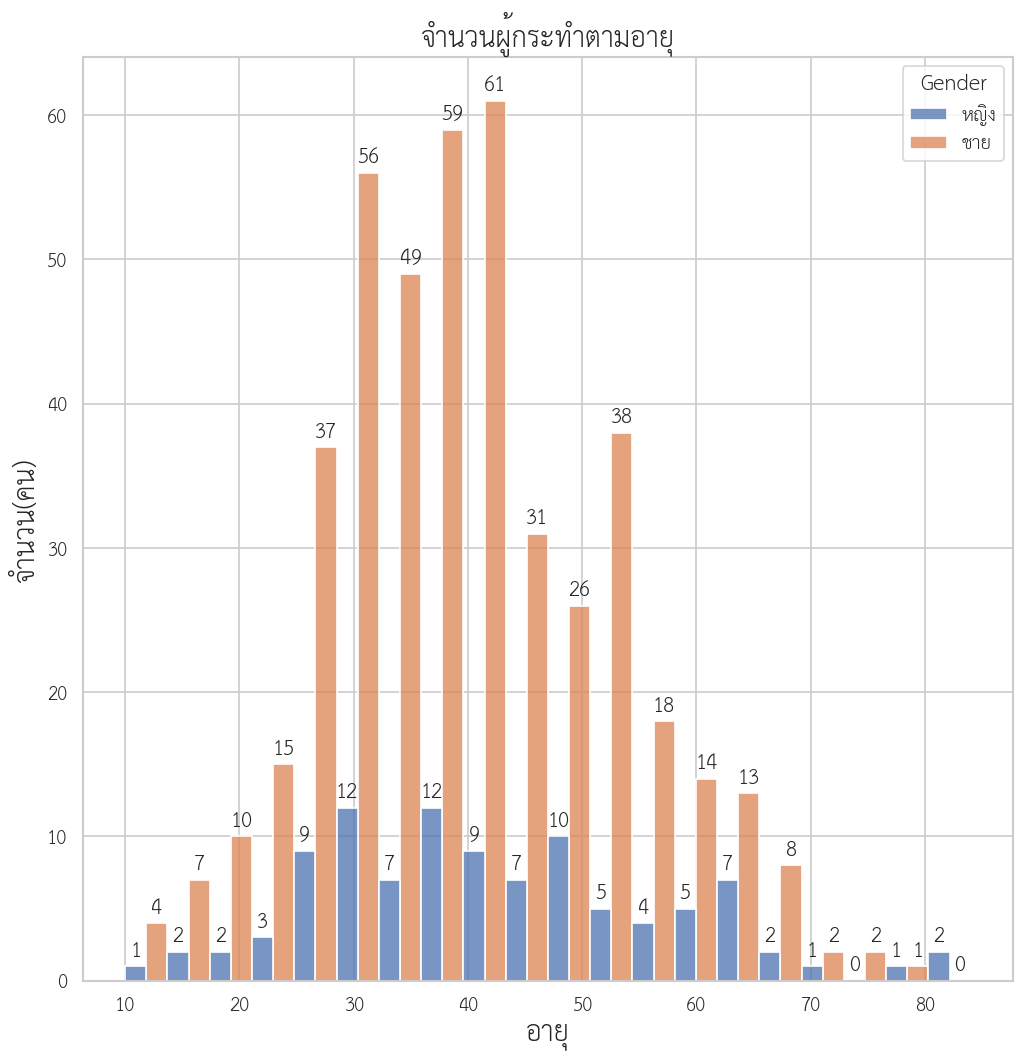

In [ ]:
plt.figure(figsize=(10, 10))
ax=sns.histplot(data=df_offender_clean,x='Age',bins=20,hue='Gender',multiple='dodge')
for i in ax.containers:
  ax.bar_label(i,fmt='%d',padding=3)
plt.title('จำนวนผู้กระทำตามอายุ',fontsize=16)
plt.xlabel('อายุ',fontsize=16)
plt.ylabel('จำนวน(คน)',fontsize=16)
plt.show()

จากข้อมูลพบว่า ผู้กระทำส่วนใหญ่เป็น **เพศชาย** และกระจุกตัวอยู่ในช่วงอายุ **30–50 ปี** โดยเฉพาะ **วัยกลางคน (36–59 ปี)** ซึ่งเป็นช่วงอายุที่พบผู้กระทำมากที่สุด


---


เมื่อพิจารณาเป็นรายอายุ พบว่า

- อายุ **42 ปี** มีจำนวนผู้กระทำสูงที่สุด (61 ราย)
- รองลงมาคือ **40 ปี** (59 ราย)


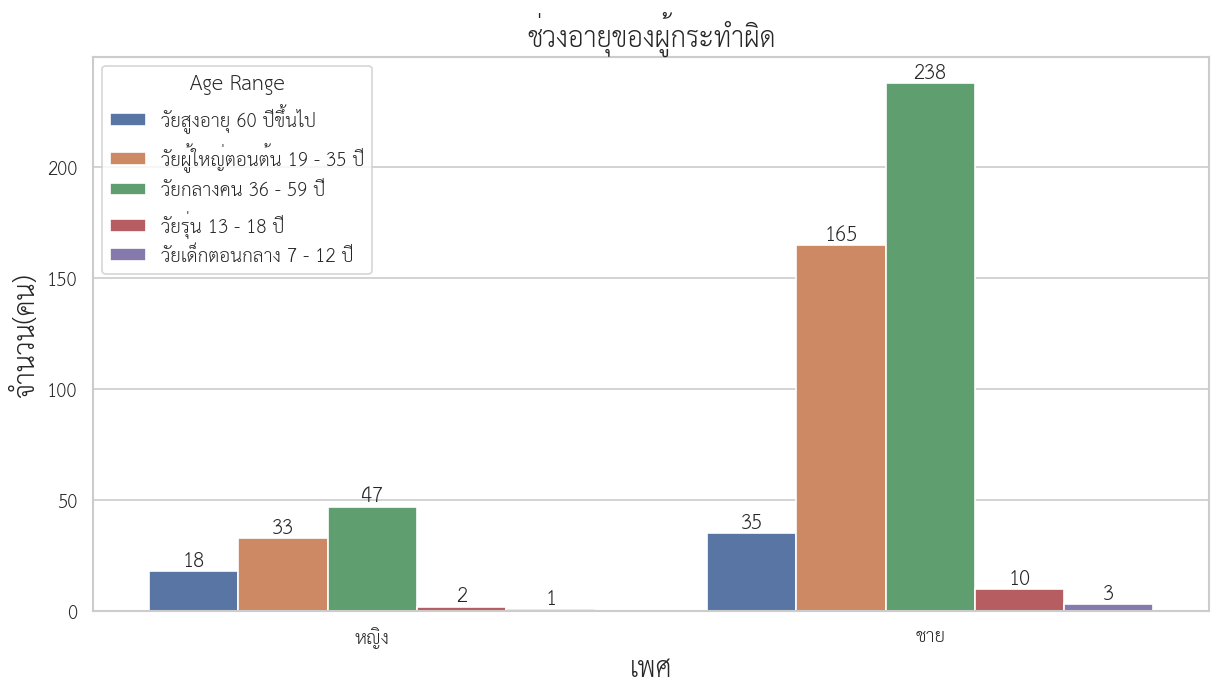

In [ ]:
plt.figure(figsize=(12, 6))

ax=sns.countplot(data=df_offender_clean, x='Gender', hue='Age Range')

for i in ax.containers:
  ax.bar_label(i)
plt.xlabel('เพศ',fontsize=16)
plt.ylabel('จำนวน(คน)',fontsize=16)
plt.title('ช่วงอายุของผู้กระทำผิด',fontsize=16)
plt.show()

ผลการวิเคราะห์สะท้อนให้เห็นว่า **ผู้กระทำหลักของชุดข้อมูลคือเพศชายในวัยทำงาน โดยเฉพาะวัยกลางคน (36–59 ปี)** ซึ่งเป็นกลุ่มประชากรที่ควรได้รับความสนใจในการวางมาตรการป้องกัน


---



## 2. ผู้กระทำส่วนใหญ่มีสถานภาพความสัมพันธ์อย่างไร?


---
# เมื่อทราบว่าผู้กระทำส่วนใหญ่เป็นเพศชายวัยกลางคน จึงวิเคราะห์ต่อในมิติของ **สถานภาพความสัมพันธ์ (Relation)**



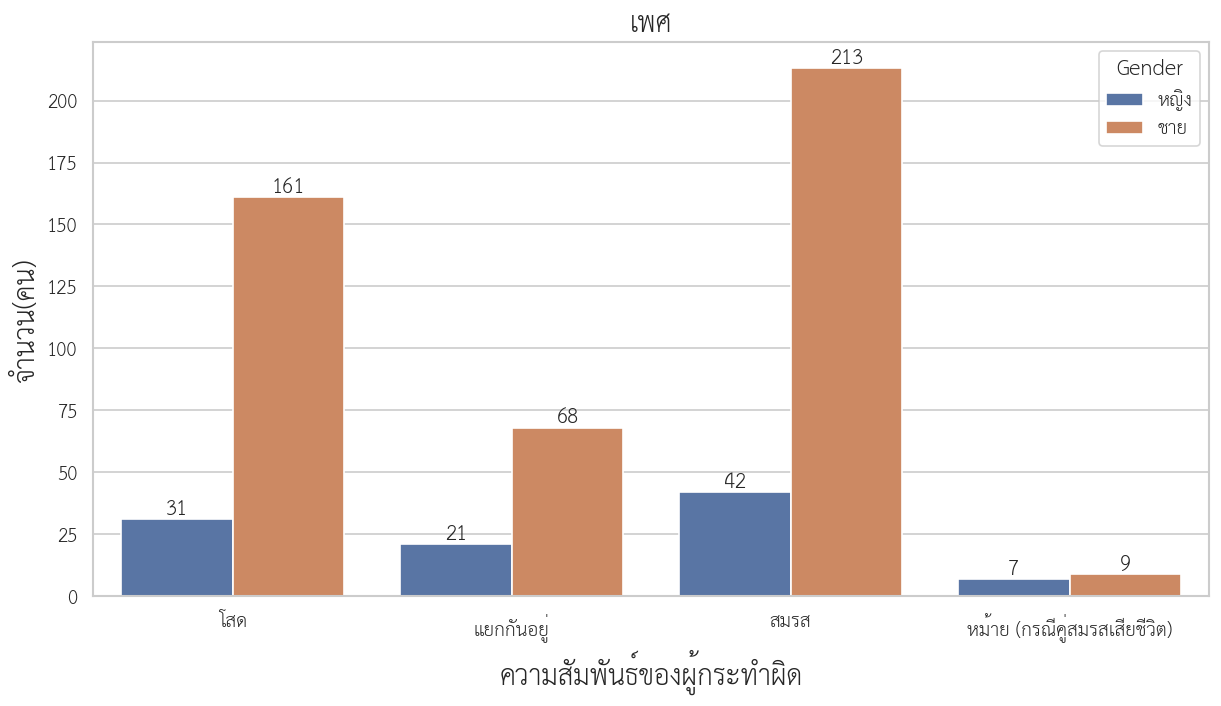

In [ ]:
plt.figure(figsize=(12, 6))

ax=sns.countplot(data=df_offender_clean, x='Relation', hue='Gender')

for i in ax.containers:
  ax.bar_label(i)
plt.xlabel('ความสัมพันธ์ของผู้กระทำผิด',fontsize=16)
plt.ylabel('จำนวน(คน)',fontsize=16)
plt.title('เพศ',fontsize=16)
plt.show()

ผลการวิเคราะห์พบว่า

- ผู้กระทำส่วนใหญ่อยู่ในสถานภาพ **สมรส**
- รองลงมาคือ **โสด**

---



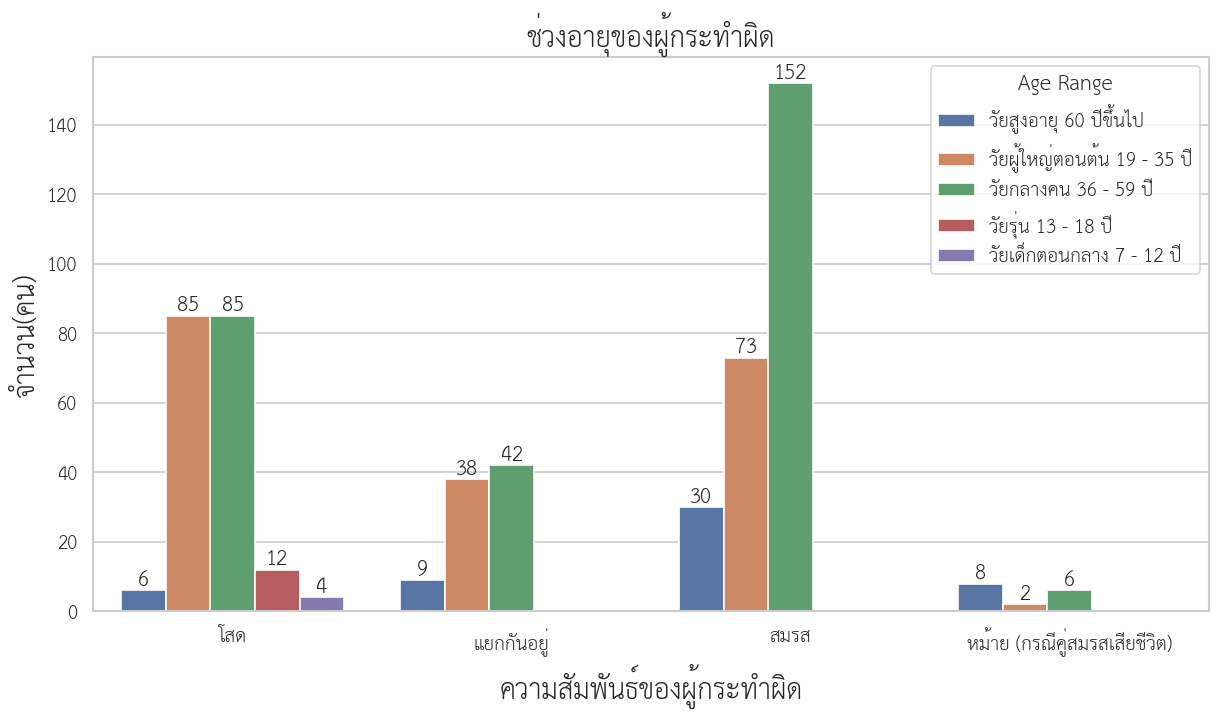

In [ ]:
plt.figure(figsize=(12, 6))

ax=sns.countplot(data=df_offender_clean, x='Relation', hue='Age Range')

for i in ax.containers:
  ax.bar_label(i)
plt.xlabel('ความสัมพันธ์ของผู้กระทำผิด',fontsize=16)
plt.ylabel('จำนวน(คน)',fontsize=16)
plt.title('ช่วงอายุของผู้กระทำผิด',fontsize=16)
plt.show()

เมื่อพิจารณาร่วมกับช่วงอายุ พบว่า

- กลุ่มวัยกลางคน (36–59 ปี) มีผู้กระทำที่อยู่ในสถานภาพ **สมรส** มากที่สุด
- รองลงมาคือกลุ่ม **โสด**


---



### Insight

จากข้อมูลสามารถสรุปได้ว่า **ผู้กระทำหลักของชุดข้อมูลคือเพศชายวัยกลางคนที่อยู่ในสถานภาพสมรส** ซึ่งสะท้อนว่าความรุนแรงส่วนใหญ่เกิดขึ้นในกลุ่มวัยสร้างครอบครัว

เมื่อได้โปรไฟล์ของผู้กระทำแล้ว จึงเกิดคำถามสำคัญว่า

> **อะไรคือปัจจัยที่กระตุ้นให้กลุ่มนี้ก่อเหตุความรุนแรง?**

---

# 3. ปัจจัยใดเป็นตัวกระตุ้นสำคัญของการก่อเหตุ?


In [ ]:
trigger_cols = ['Alcohol', 'Drug', 'Authoritative', 'Rage', 'Jealous',
                'Divorce', 'Health Problem', 'Mental Problem',
                'Gambling Addict', 'Economics Stress']

is_no = (df_offender_clean[trigger_cols] == 'ไม่')

trigger_counts = is_no.sum()


trigger_ranked = trigger_counts.sort_values(ascending=False)

print(trigger_ranked)

Gambling Addict     539
Divorce             535
Health Problem      534
Economics Stress    479
Mental Problem      463
Jealous             440
Authoritative       411
Rage                387
Alcohol             378
Drug                350
dtype: int64


In [ ]:
trigger_cols = ['Alcohol', 'Drug', 'Authoritative', 'Rage', 'Jealous',
                'Divorce', 'Health Problem', 'Mental Problem',
                'Gambling Addict', 'Economics Stress']

is_yes = (df_offender_clean[trigger_cols] == 'ใช่')

trigger_counts = is_yes.sum()


trigger_ranked = trigger_counts.sort_values(ascending=False)

print(trigger_ranked)

Drug                202
Alcohol             174
Rage                165
Authoritative       141
Jealous             112
Mental Problem       89
Economics Stress     73
Health Problem       18
Divorce              17
Gambling Addict      13
dtype: int64


จากการวิเคราะห์ปัจจัยเสี่ยงของผู้กระทำ พบว่าปัจจัยที่ถูกบันทึกมากที่สุด ได้แก่

| Trigger | จำนวน |
|---------|------:|
| Drug | 202 |
| Alcohol | 174 |
| Rage | 165 |
| Authoritative | 141 |

แสดงให้เห็นว่า **ยาเสพติด แอลกอฮอล์ และการบันดาลโทสะ** เป็นปัจจัยที่พบมากที่สุดในชุดข้อมูล

อย่างไรก็ตาม การเรียงลำดับจำนวนเพียงอย่างเดียวยังไม่สามารถอธิบายได้ว่า **ปัจจัยเหล่านี้เกิดขึ้นกับผู้กระทำกลุ่มใด** จึงทำการวิเคราะห์เชิงลึกเพิ่มเติม


# 4. Trigger แต่ละประเภทเกิดกับผู้กระทำกลุ่มใด?

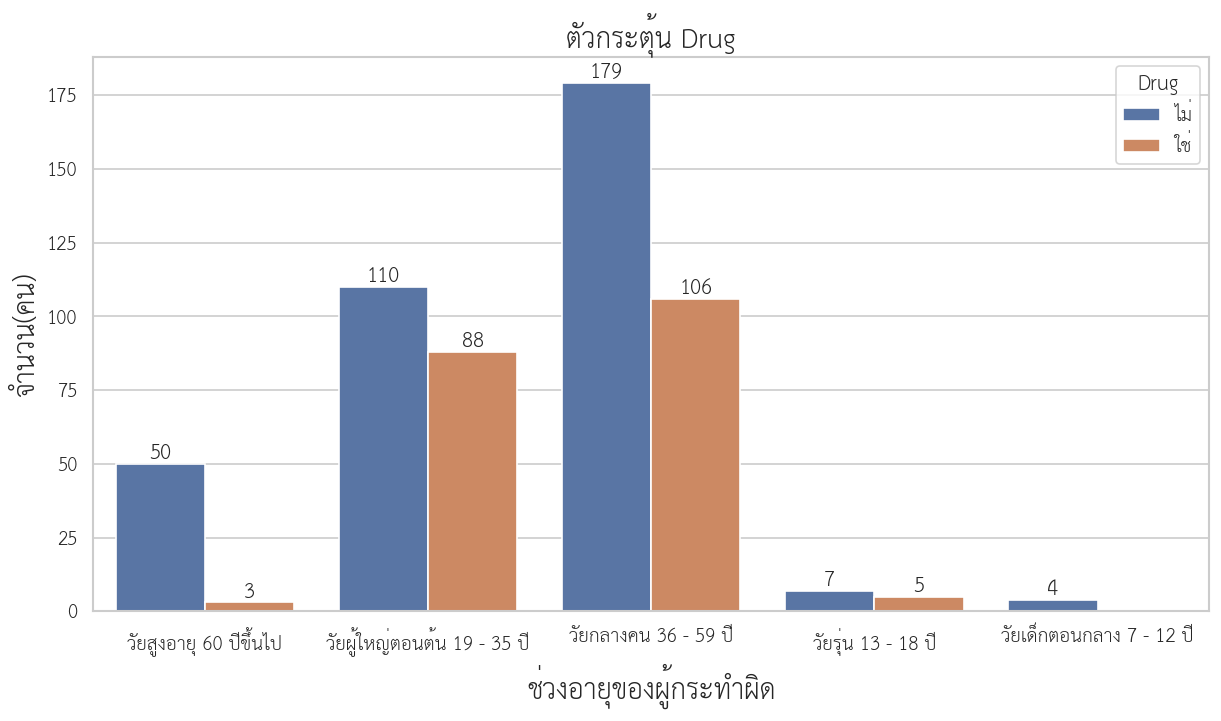

In [ ]:
plt.figure(figsize=(12, 6))

ax=sns.countplot(
    data=df_offender_clean,
    x='Age Range',
    hue='Drug',
)
for i in ax.containers:
  ax.bar_label(i)

plt.xlabel('ช่วงอายุของผู้กระทำผิด',fontsize=16)
plt.ylabel('จำนวน(คน)',fontsize=16)
plt.title('ตัวกระตุ้น Drug',fontsize=16)
plt.show()

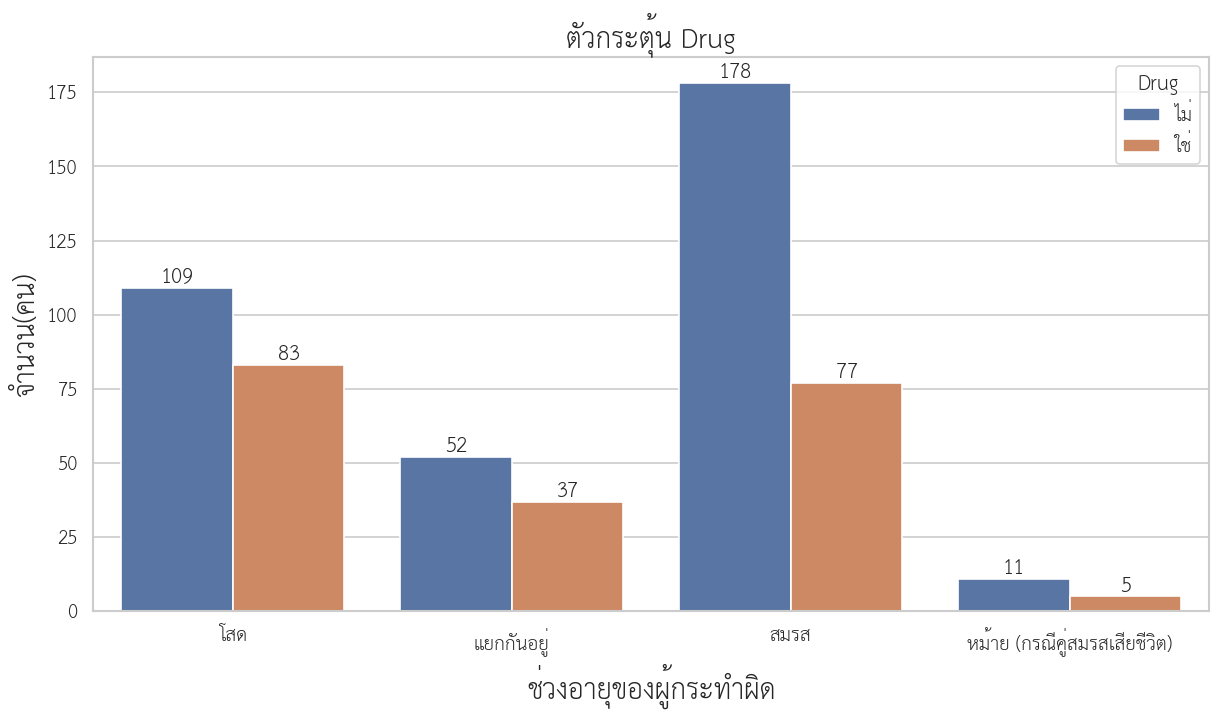

In [ ]:
plt.figure(figsize=(12, 6))

ax=sns.countplot(
    data=df_offender_clean,
    x='Relation',
    hue='Drug',
)
for i in ax.containers:
  ax.bar_label(i)

plt.xlabel('ช่วงอายุของผู้กระทำผิด',fontsize=16)
plt.ylabel('จำนวน(คน)',fontsize=16)
plt.title('ตัวกระตุ้น Drug',fontsize=16)
plt.show()



---



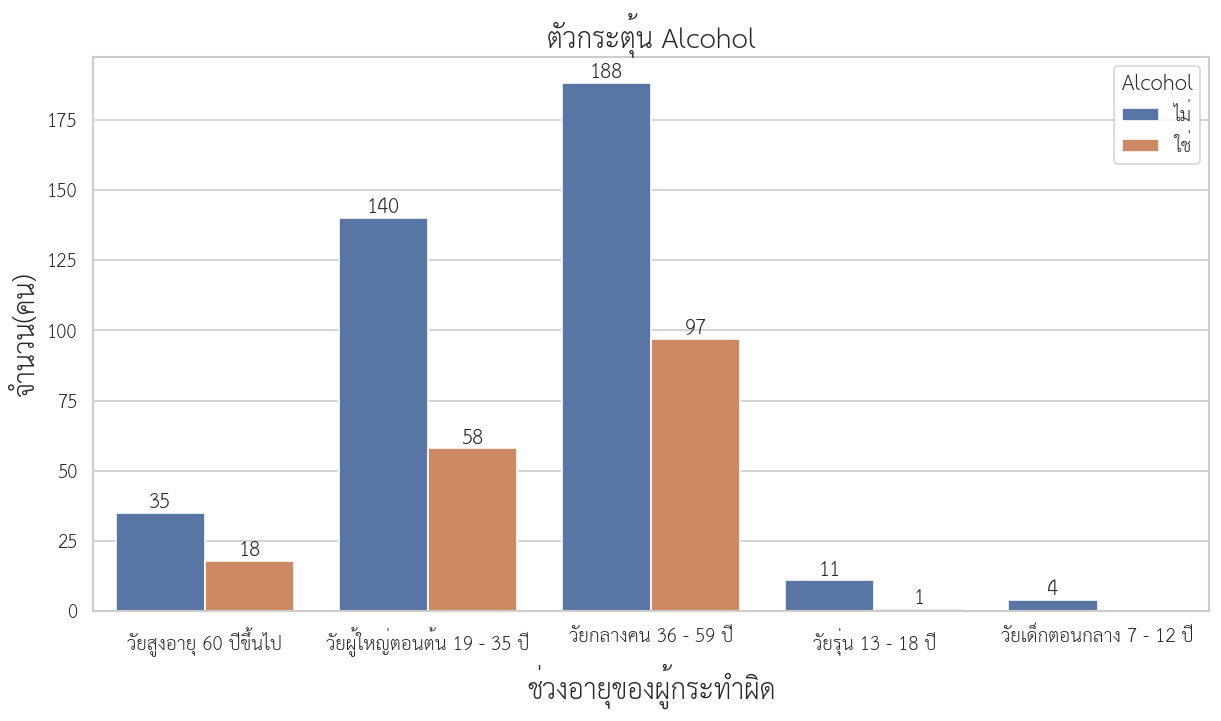

In [ ]:
plt.figure(figsize=(12, 6))

ax=sns.countplot(
    data=df_offender_clean,
    x='Age Range',
    hue='Alcohol',
)
for i in ax.containers:
  ax.bar_label(i)

plt.xlabel('ช่วงอายุของผู้กระทำผิด',fontsize=16)
plt.ylabel('จำนวน(คน)',fontsize=16)
plt.title('ตัวกระตุ้น Alcohol',fontsize=16)
plt.show()



---



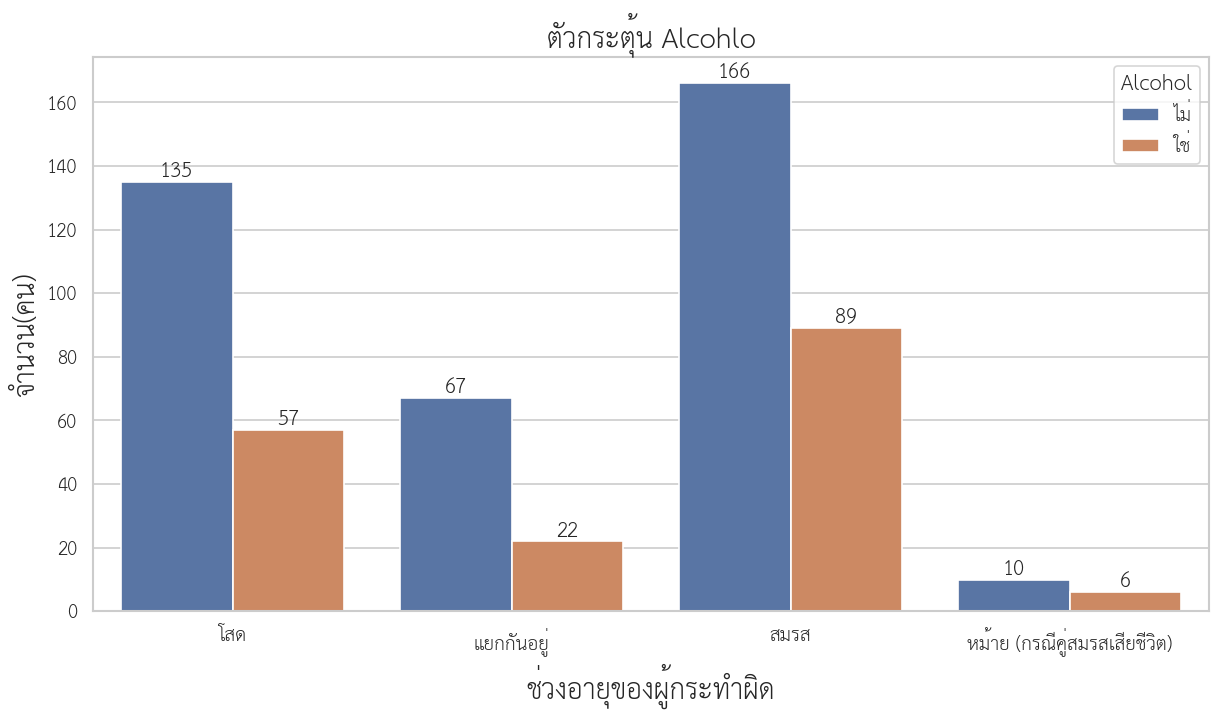

In [ ]:
plt.figure(figsize=(12, 6))

ax=sns.countplot(
    data=df_offender_clean,
    x='Relation',
    hue='Alcohol',
)
for i in ax.containers:
  ax.bar_label(i)

plt.xlabel('ช่วงอายุของผู้กระทำผิด',fontsize=16)
plt.ylabel('จำนวน(คน)',fontsize=16)
plt.title('ตัวกระตุ้น Alcohlo',fontsize=16)
plt.show()

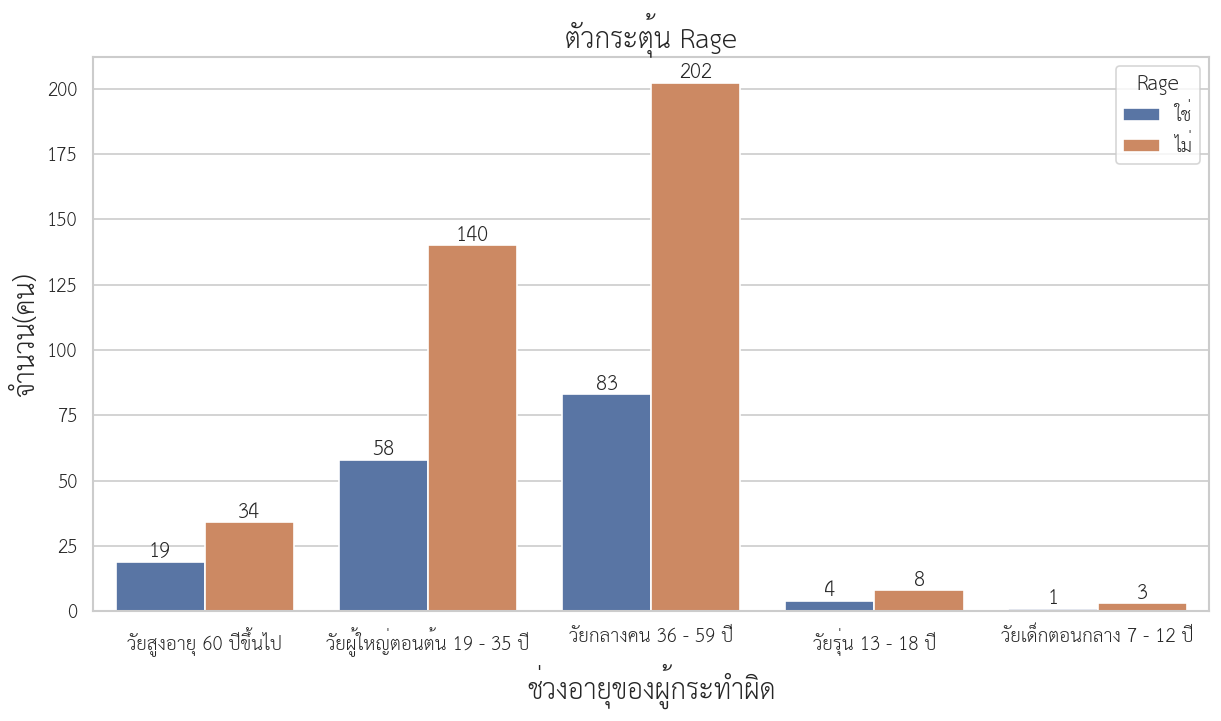

In [ ]:
plt.figure(figsize=(12, 6))

ax=sns.countplot(
    data=df_offender_clean,
    x='Age Range',
    hue='Rage',
)
for i in ax.containers:
  ax.bar_label(i)

plt.xlabel('ช่วงอายุของผู้กระทำผิด',fontsize=16)
plt.ylabel('จำนวน(คน)',fontsize=16)
plt.title('ตัวกระตุ้น Rage',fontsize=16)
plt.show()

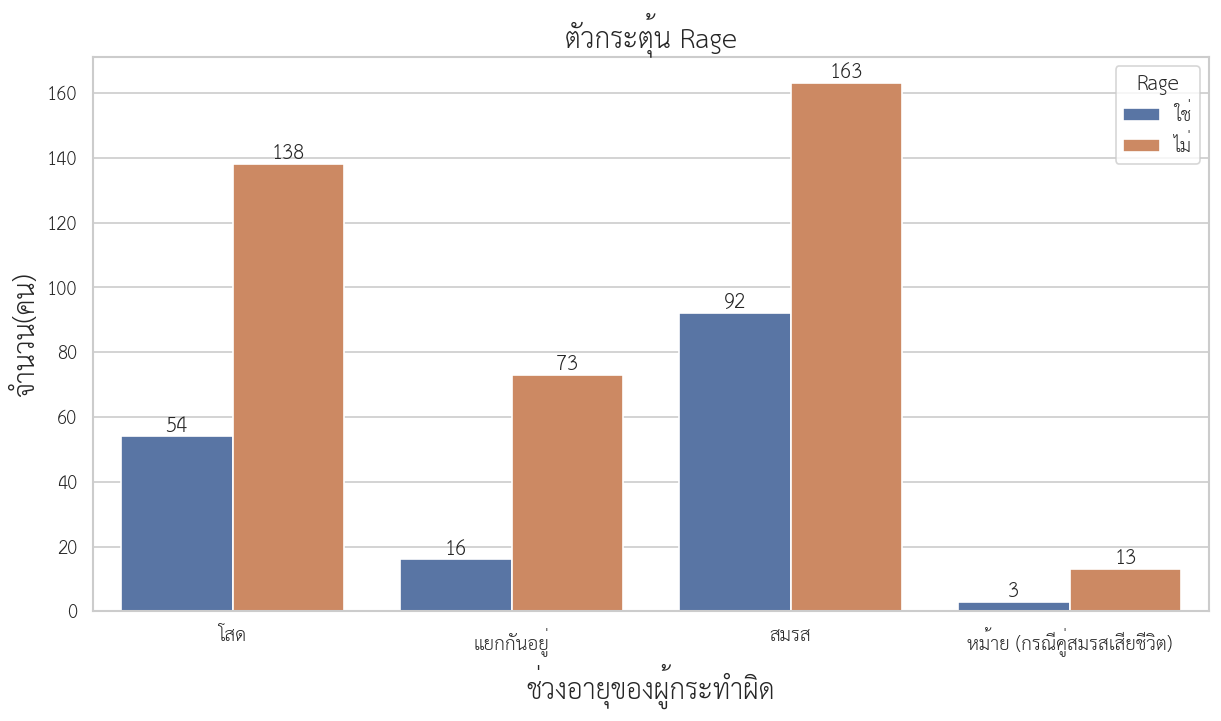

In [ ]:
plt.figure(figsize=(12, 6))

ax=sns.countplot(
    data=df_offender_clean,
    x='Relation',
    hue='Rage',
)
for i in ax.containers:
  ax.bar_label(i)

plt.xlabel('ช่วงอายุของผู้กระทำผิด',fontsize=16)
plt.ylabel('จำนวน(คน)',fontsize=16)
plt.title('ตัวกระตุ้น Rage',fontsize=16)
plt.show()

มื่อนำปัจจัยกระตุ้นมาวิเคราะห์ร่วมกับข้อมูลประชากรศาสตร์ พบว่า

| Trigger | ช่วงอายุที่พบมากที่สุด | Relation ที่พบมากที่สุด |
|----------|----------------------|-----------------------|
| Drug | วัยกลางคน (106) | โสด (83) |
| Alcohol | วัยกลางคน (97) | สมรส (89) |
| Rage | วัยกลางคน (83) | สมรส (92) |

### Insight

เมื่อเปรียบเทียบปัจจัยกระตุ้นหลักทั้งสาม พบว่า **ทุกปัจจัยกระจุกตัวอยู่ในวัยกลางคน (36–59 ปี)** แสดงให้เห็นว่าวัยกลางคนเป็นกลุ่มเสี่ยงหลักของผู้กระทำ ไม่ว่าปัจจัยกระตุ้นจะเป็นประเภทใด

อย่างไรก็ตาม รูปแบบของสถานภาพความสัมพันธ์มีความแตกต่างกัน

- **Alcohol และ Rage** พบมากในกลุ่มผู้กระทำที่มีสถานภาพ **สมรส**
- **Drug** พบมากในกลุ่มผู้กระทำที่มีสถานภาพ **โสด**

ผลลัพธ์นี้สะท้อนว่า แม้ว่าปัจจัยกระตุ้นทั้งหมดจะเกิดขึ้นในกลุ่มวัยกลางคนเป็นหลัก แต่ปัจจัยแต่ละประเภทมีรูปแบบของผู้กระทำที่แตกต่างกัน


---




# บทสรุป

จากการวิเคราะห์ข้อมูลเชิงประชากรศาสตร์และปัจจัยกระตุ้น สามารถสร้างโปรไฟล์ของผู้กระทำความรุนแรงในครอบครัวได้ดังนี้

- ผู้กระทำส่วนใหญ่เป็น **เพศชาย**
- อยู่ในช่วง **วัยกลางคน (36–59 ปี)**
- ส่วนใหญ่อยู่ในสถานภาพ **สมรส**
- ปัจจัยกระตุ้นที่พบมากที่สุด ได้แก่ **ยาเสพติด แอลกอฮอล์ และการบันดาลโทสะ**

เมื่อวิเคราะห์เชิงลึกพบว่า แม้ทั้งสามปัจจัยจะกระจุกตัวอยู่ในวัยกลางคนเหมือนกัน แต่มีความแตกต่างในด้านสถานภาพความสัมพันธ์ โดย **ยาเสพติดพบในกลุ่มโสดมากกว่า ขณะที่แอลกอฮอล์และการบันดาลโทสะพบมากในกลุ่มสมรส** ซึ่งแสดงให้เห็นว่าปัจจัยกระตุ้นแต่ละประเภทอาจมีรูปแบบของผู้กระทำที่แตกต่างกัน และควรได้รับการศึกษาเชิงลึกเพิ่มเติมเพื่อสนับสนุนการออกแบบมาตรการป้องกันในอนาคต